# STAT 4830 — Token-Level Slop Classifier Notebook

This notebook implements the **transformer-based slop classifier**.

## What this notebook does
1. Loads a **human essay** dataset (`essays.csv`).
2. Builds a first-pass **slop dataset** by corrupting human text into "sloppier" text.
3. Trains a **frozen-transformer logistic regression baseline**.
4. Trains a **token-level slop classifier** on top of a pretrained **causal transformer**.
5. Aggregates token slop probabilities into a **document-level slop score**.
6. Visualizes **which parts of a text look most slop-like**.

Mathematically, for tokens \(x_1,\dots,x_T\):
\[
h_t = \mathrm{Transformer}(x)_t
\]
\[
p_t = \sigma(w^\top h_t + b)
\]
\[
\hat y(x) = \frac{\sum_{t=1}^T m_t p_t}{\sum_{t=1}^T m_t}
\]
where \(m_t\) is the attention mask and \(\hat y(x)\) is the document-level slop score.

We then optimize:
\[
\min_\theta \sum_i \mathrm{BCE}(\hat y(x^{(i)}), y^{(i)})
\]

## Important note
This notebook uses **weak supervision**:
- document labels are available (`human` vs `slop`)
- token labels are **not** available yet
- so token-level slop probabilities are learned **indirectly** from document-level labels


## 0) Runtime and usage notes

### Recommended runtime
- **Colab GPU** strongly recommended
- T4 / L4 is more than enough for this notebook
- CPU also works, but training and embedding extraction will be slower

### Expected inputs
This notebook assumes you have an `essays.csv` file available in the notebook runtime.

Expected columns are the same as your earlier verifier notebook:
- `essay`
- optionally `title`, `description`, etc.

### Main implementation choices
To keep this notebook **single-run and reliable**, it uses:
- a **corruption-based slop generator** (simple, deterministic, fast)
- a **frozen-transformer logistic regression baseline**
- a **token-level weakly supervised classifier** using `distilgpt2`

Later, you can replace the corruption generator with:
- stronger prompted slop
- a dedicated slopifier
- a locally run LLM
- a fine-tuned generator


In [4]:
# If running in Colab, uncomment:
!pip -q install transformers datasets accelerate scikit-learn pandas matplotlib tqdm

In [5]:
import os
import re
import math
import json
import random
import textwrap
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1) Configuration

These settings are deliberately conservative so the notebook runs in one go.
You can scale `MAX_HUMAN_SAMPLES`, `MAX_LEN`, or `EPOCHS` later.


In [6]:
# =========================
# Configuration
# =========================

DATA_PATH = "essays.csv"   # change this if needed
TEXT_COL = "essay"

MAX_HUMAN_SAMPLES = 1200            # cap for fast experimentation
MIN_CHAR_LEN = 500                  # keep long-enough samples
MAX_CHAR_LEN = 12000

# Transformer backbone for both baseline embeddings and token-level classifier
MODEL_NAME = "distilgpt2"

# Tokenization / training
MAX_LEN = 256
TRAIN_BS = 8
EVAL_BS = 16
LR = 2e-5
EPOCHS = 3
WEIGHT_DECAY = 0.01
DROPOUT = 0.1
GRAD_CLIP = 1.0

# Corruption controls for slop generation
NGRAM_REPEAT_TIMES = 3
SHUFFLE_SENTENCE_FRAC = 0.35
FILLER_PROB = 0.75

# You can reduce these if memory is tight
EMBED_BATCH_SIZE = 16

assert os.path.exists(DATA_PATH), f"Could not find DATA_PATH={DATA_PATH}"
print("Using DATA_PATH:", DATA_PATH)

Using DATA_PATH: essays.csv


## 2) Load human essays

We reuse the same basic setup as your earlier verifier notebook:
- load essays from CSV
- keep the main essay text
- filter by length
- sample a manageable subset


In [7]:
df_raw = pd.read_csv(DATA_PATH)
print("raw shape:", df_raw.shape)
print("columns:", list(df_raw.columns))

assert TEXT_COL in df_raw.columns, f"Expected a '{TEXT_COL}' column in essays.csv"

df_human = df_raw[[TEXT_COL]].copy()
df_human = df_human.rename(columns={TEXT_COL: "text"})
df_human["text"] = df_human["text"].astype(str).str.strip()

df_human = df_human[df_human["text"].str.len().between(MIN_CHAR_LEN, MAX_CHAR_LEN)]
df_human = df_human.drop_duplicates(subset=["text"]).reset_index(drop=True)

if len(df_human) > MAX_HUMAN_SAMPLES:
    df_human = df_human.sample(MAX_HUMAN_SAMPLES, random_state=SEED).reset_index(drop=True)

df_human["label"] = 1   # 1 = human
print("filtered human shape:", df_human.shape)
df_human.head()

raw shape: (2235, 6)
columns: ['title', 'description', 'essay', 'authors', 'source_url', 'thumbnail_url']
filtered human shape: (84, 2)


,text,label
0,"How much fear, anxiety and risk can children h...",1
1,I killed my dog last year. Mika was a shelter ...,1
2,There’s a well-known contradiction in the way ...,1
3,"In late 2016, a team of palaeontologists, led ...",1
4,"‘Nothing is more difficult,’ wrote the German ...",1


## 3) Build a first-pass slop dataset

### Why use a corruption-based generator here?
For this notebook, we have a **working implementation** of the classifier idea.

So we generate slop by **corrupting human text**:
- sentence shuffling
- repeated phrases
- generic filler insertion
- some over-redundancy

This gives us a fast and controllable first-pass slop dataset.

Later, we will replace this with:
- stronger LLM prompting
- a local model such as Kimi
- a dedicated slopifier


In [8]:
FILLER_PREFIXES = [
    "In conclusion, it is important to note that ",
    "Overall, one could say that ",
    "It should be said that ",
    "Generally speaking, it is worth mentioning that ",
    "From many different perspectives, we can see that ",
]

def split_sentences(text):
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    sents = [s.strip() for s in sents if s.strip()]
    return sents

def repeat_ngram(text, n=10, times=3):
    toks = text.split()
    if len(toks) < n + 5:
        return text
    ngram = " ".join(toks[:n])
    return f"{ngram} " * times + text

def shuffle_some_sentences(text, frac=0.35):
    sents = split_sentences(text)
    if len(sents) < 4:
        return text
    k = max(2, int(len(sents) * frac))
    idx = list(range(len(sents)))
    chosen = idx[:k]
    sub = [sents[i] for i in chosen]
    random.shuffle(sub)
    out = sents[:]
    for i, s in zip(chosen, sub):
        out[i] = s
    return " ".join(out)

def inject_filler(text):
    prefix = random.choice(FILLER_PREFIXES)
    return prefix + text

def lightly_paraphrase_by_duplication(text):
    sents = split_sentences(text)
    if len(sents) < 3:
        return text
    out = []
    for s in sents:
        out.append(s)
        if random.random() < 0.25:
            out.append(s)  # duplicate some content
    return " ".join(out)

def corrupt_to_slop(text):
    x = text
    if random.random() < FILLER_PROB:
        x = inject_filler(x)
    x = repeat_ngram(x, n=10, times=NGRAM_REPEAT_TIMES)
    x = shuffle_some_sentences(x, frac=SHUFFLE_SENTENCE_FRAC)
    x = lightly_paraphrase_by_duplication(x)
    return x

df_slop = df_human.copy()
df_slop["text"] = df_slop["text"].apply(corrupt_to_slop)
df_slop["label"] = 0   # 0 = slop

print("human:", df_human.shape, "slop:", df_slop.shape)
print("\nExample HUMAN snippet:\n")
print(df_human.loc[0, "text"][:500])
print("\n\nExample SLOP snippet:\n")
print(df_slop.loc[0, "text"][:500])

human: (84, 2) slop: (84, 2)

Example HUMAN snippet:

How much fear, anxiety and risk can children handle? Until the late 19th century, most people thought that the answer was quite a lot. Aristotle himself said that education might be defined as teaching us to fear aright. It was widely believed that a sense of fear made a positive contribution to the formation of a child’s character. That fear was regarded as essential for the education of children was spelled out by the Church Missionary Society in 1819, when it stated that ‘it is necessary, tha


Example SLOP snippet:

And he had another insight: these ‘unwise fears’ were often attributable to incompetent parenting. His studies, carried out in the 1890s, called for a reorientation. Most modern parents would no more try to frighten a child than they would beat the child with whips or send that child to a year of hard labour on a chain gang, but feel stymied by the onslaught of the world. Most modern parents would no more try to frig

## 4) Build labeled dataset + train/val/test split

We now combine:
- `human` texts with label 1
- `slop` texts with label 0

This gives document-level supervision for the token classifier.


In [9]:
df_all = pd.concat([df_human, df_slop], axis=0, ignore_index=True)
df_all = df_all.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df_all, test_size=0.30, random_state=SEED, stratify=df_all["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, d.shape, d["label"].value_counts().to_dict())

train (117, 2) {1: 59, 0: 58}
val (25, 2) {0: 13, 1: 12}
test (26, 2) {1: 13, 0: 13}


## 5) Tokenizer + backbone

We use a **causal transformer** backbone (`distilgpt2`):
- text passes through transformer
- we use the **final hidden state per token**
- then attach a **token-level classifier head**

Important:
- GPT-style tokenizers do not define a pad token by default
- we set `pad_token = eos_token`


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

backbone_for_baseline = AutoModel.from_pretrained(MODEL_NAME)
backbone_for_baseline.to(device)
backbone_for_baseline.eval()

hidden_size = backbone_for_baseline.config.hidden_size
print("hidden_size:", hidden_size)
print("pad_token_id:", tokenizer.pad_token_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


hidden_size: 768
pad_token_id: 50256


## 6) Baseline 1 — frozen transformer embeddings + logistic regression
Before training the full token-level head, we build an easy baseline:
- run text through a **frozen pretrained transformer**
- mean-pool the hidden states
- train a **logistic regression classifier**

This answers:
**How good are frozen transformer features before we do token-level training?**


In [11]:
def embed_texts_mean_pool(texts, tokenizer, backbone, max_len=256, batch_size=16):
    all_vecs = []
    backbone.eval()
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = backbone(**enc, return_dict=True)
            hidden = out.last_hidden_state                 # [B, T, H]
            mask = enc["attention_mask"].unsqueeze(-1)    # [B, T, 1]
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            all_vecs.append(pooled.detach().cpu().numpy())
    return np.concatenate(all_vecs, axis=0)

X_train = embed_texts_mean_pool(
    train_df["text"].tolist(), tokenizer, backbone_for_baseline,
    max_len=MAX_LEN, batch_size=EMBED_BATCH_SIZE
)
X_val = embed_texts_mean_pool(
    val_df["text"].tolist(), tokenizer, backbone_for_baseline,
    max_len=MAX_LEN, batch_size=EMBED_BATCH_SIZE
)
X_test = embed_texts_mean_pool(
    test_df["text"].tolist(), tokenizer, backbone_for_baseline,
    max_len=MAX_LEN, batch_size=EMBED_BATCH_SIZE
)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

logreg = LogisticRegression(max_iter=2000, random_state=SEED)
logreg.fit(X_train, y_train)

val_probs = logreg.predict_proba(X_val)[:, 1]
test_probs = logreg.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("=== Frozen-transformer logistic regression baseline ===")
print("Val AUC:", roc_auc_score(y_val, val_probs))
print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("Test F1:", f1_score(y_test, test_preds))
print("Test AUC:", roc_auc_score(y_test, test_probs))
print("Confusion matrix:\n", confusion_matrix(y_test, test_preds))

Embedding:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding:   0%|          | 0/2 [00:00<?, ?it/s]

=== Frozen-transformer logistic regression baseline ===
Val AUC: 0.8397435897435898
Test Accuracy: 0.8846153846153846
Test F1: 0.88
Test AUC: 0.9644970414201183
Confusion matrix:
 [[12  1]
 [ 2 11]]


## 7) Dataset class for token-level weak supervision

We still only have **document labels**, not token labels.

So each example contains:
- `input_ids`
- `attention_mask`
- document label (`human` vs `slop`)

The token classifier will output a score per token, then aggregate to a document score.


In [12]:
class SlopDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float),
            "raw_text": self.texts[idx]
        }

train_ds = SlopDataset(train_df, tokenizer, max_len=MAX_LEN)
val_ds = SlopDataset(val_df, tokenizer, max_len=MAX_LEN)
test_ds = SlopDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=TRAIN_BS, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=EVAL_BS, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=EVAL_BS, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)

(117, 25, 26)

## 8) Token-level slop classifier

### Architecture
1. Text goes through pretrained transformer backbone
2. We take the **final hidden state for each token**
3. A small linear head predicts a **slop logit per token**
4. We apply sigmoid to get **token-level slop probabilities**
5. We aggregate token probabilities with a **masked mean**
6. That produces a **document-level slop score**


In [13]:
class GPTTokenSlopClassifier(nn.Module):
    def __init__(self, model_name="distilgpt2", dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.backbone.config.pad_token_id = tokenizer.pad_token_id
        hidden_size = self.backbone.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.token_classifier = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        hidden = out.last_hidden_state                   # [B, T, H]
        hidden = self.dropout(hidden)

        token_logits = self.token_classifier(hidden).squeeze(-1)   # [B, T]
        token_probs = torch.sigmoid(token_logits)                  # [B, T]

        mask = attention_mask.float()
        doc_score = (token_probs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

        loss = None
        if labels is not None:
            labels = labels.float()
            loss_fn = nn.BCELoss()
            loss = loss_fn(doc_score, labels)

        return {
            "loss": loss,
            "token_logits": token_logits,
            "token_probs": token_probs,
            "doc_score": doc_score
        }

model = GPTTokenSlopClassifier(MODEL_NAME, dropout=DROPOUT).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

num_training_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * num_training_steps)),
    num_training_steps=num_training_steps
)

sum(p.numel() for p in model.parameters()) / 1e6

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


81.913345

## 9) Training loop

We train using **document-level BCE loss** on the aggregated slop score.

Remember:
- token probabilities are learned **indirectly**
- they are not token-level ground truth labels
- they are best interpreted as **weakly supervised slop saliency scores**


In [14]:
def run_eval(model, loader):
    model.eval()
    all_probs, all_labels, all_loss = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out["loss"]

            all_loss.append(loss.item())
            all_probs.extend(out["doc_score"].detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)

    metrics = {
        "loss": float(np.mean(all_loss)),
        "acc": accuracy_score(all_labels, preds),
        "f1": f1_score(all_labels, preds),
        "auc": roc_auc_score(all_labels, all_probs),
    }
    return metrics, all_labels, all_probs

best_val_auc = -1
best_state = None
history = []

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        train_losses.append(loss.item())

    val_metrics, _, _ = run_eval(model, val_loader)
    row = {
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    history.append(row)
    print(row)

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

hist_df = pd.DataFrame(history)
hist_df

Epoch 1/3:   0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7960797667503356, 'val_loss': 0.6648190021514893, 'val_acc': 0.56, 'val_f1': 0.6857142857142857, 'val_auc': np.float64(0.7948717948717948)}


Epoch 2/3:   0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.6223503033320109, 'val_loss': 0.6284932196140289, 'val_acc': 0.8, 'val_f1': 0.8275862068965517, 'val_auc': np.float64(0.858974358974359)}


Epoch 3/3:   0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.5939761678377787, 'val_loss': 0.6192875802516937, 'val_acc': 0.8, 'val_f1': 0.8275862068965517, 'val_auc': np.float64(0.891025641025641)}


,epoch,train_loss,val_loss,val_acc,val_f1,val_auc
0,1,0.796080,0.664819,0.56,0.685714,0.794872
1,2,0.622350,0.628493,0.80,0.827586,0.858974
2,3,0.593976,0.619288,0.80,0.827586,0.891026


## 10) Final evaluation

We evaluate the token-level weakly supervised classifier at the **document level** first.
This keeps the comparison fair with the earlier verifier setup.


=== Token-level weakly supervised classifier (document-level eval) ===
{
  "loss": 0.627474457025528,
  "acc": 0.6923076923076923,
  "f1": 0.7142857142857143,
  "auc": 0.8402366863905326
}

Confusion matrix:
 [[ 8  5]
 [ 3 10]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.7273    0.6154    0.6667        13
         1.0     0.6667    0.7692    0.7143        13

    accuracy                         0.6923        26
   macro avg     0.6970    0.6923    0.6905        26
weighted avg     0.6970    0.6923    0.6905        26



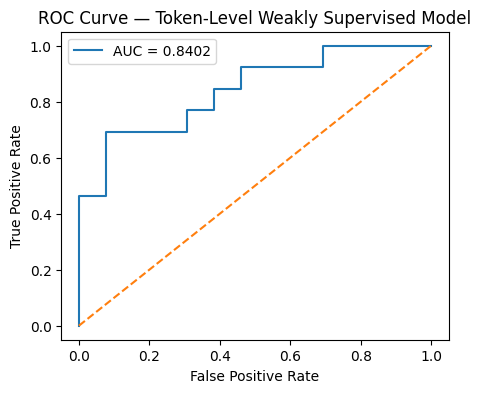

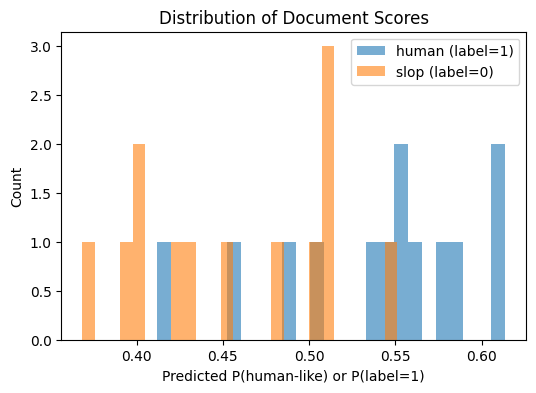

In [15]:
model.load_state_dict(best_state)

test_metrics, test_labels, test_probs = run_eval(model, test_loader)
test_preds = (test_probs >= 0.5).astype(int)

print("=== Token-level weakly supervised classifier (document-level eval) ===")
print(json.dumps(test_metrics, indent=2))
print("\nConfusion matrix:\n", confusion_matrix(test_labels, test_preds))
print("\nClassification report:\n", classification_report(test_labels, test_preds, digits=4))

fpr, tpr, _ = roc_curve(test_labels, test_probs)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {test_metrics['auc']:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Token-Level Weakly Supervised Model")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(test_probs[test_labels == 1], bins=25, alpha=0.6, label="human (label=1)")
plt.hist(test_probs[test_labels == 0], bins=25, alpha=0.6, label="slop (label=0)")
plt.xlabel("Predicted P(human-like) or P(label=1)")
plt.ylabel("Count")
plt.title("Distribution of Document Scores")
plt.legend()
plt.show()

## 11) Inspect token-level slop scores
For a single document, we can now compute:
- a **document-level score**
- a **token-level slop probability**
- the **fraction of tokens** that look slop-like

This gives a more detailed picture than a single sequence label.


In [16]:
def score_single_text(model, text, tokenizer, max_len=256, threshold=0.5):
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attention_mask)

    token_probs = out["token_probs"][0].detach().cpu().numpy()
    doc_score = float(out["doc_score"][0].detach().cpu().item())

    input_ids_cpu = enc["input_ids"][0].tolist()
    attn_cpu = enc["attention_mask"][0].tolist()

    toks = tokenizer.convert_ids_to_tokens(input_ids_cpu)
    pairs = []
    for tok, p, m in zip(toks, token_probs, attn_cpu):
        if m == 0:
            continue
        clean_tok = tok.replace("Ġ", " ")
        pairs.append((clean_tok, float(p)))

    frac_slop = np.mean([p > threshold for _, p in pairs]) if pairs else 0.0

    return {
        "doc_score": doc_score,
        "frac_slop_tokens": float(frac_slop),
        "token_pairs": pairs
    }

def render_token_heatmap(token_pairs, width=120):
    html_parts = []
    for tok, p in token_pairs:
        # red intensity grows with p
        alpha = min(0.90, max(0.05, p))
        span = f'<span style="background-color: rgba(255,0,0,{alpha:.2f}); padding:2px; margin:1px; border-radius:3px;">{tok}</span>'
        html_parts.append(span)
    return "".join(html_parts)

from IPython.display import HTML, display

example_text = test_df.iloc[0]["text"]
example_label = test_df.iloc[0]["label"]

scored = score_single_text(model, example_text, tokenizer, max_len=MAX_LEN, threshold=0.5)
print("true label:", example_label)
print("document score:", scored["doc_score"])
print("fraction slop-like tokens:", scored["frac_slop_tokens"])

display(HTML(render_token_heatmap(scored["token_pairs"])))

true label: 1
document score: 0.5823227763175964
fraction slop-like tokens: 0.671875


## 12) Compare most human-like slop and most slop-like human examples

This mirrors the qualitative analysis style from your earlier verifier notebook.
It helps diagnose whether the model is learning sensible patterns.


In [17]:
def predict_dataframe_scores(model, df, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            probs.extend(out["doc_score"].detach().cpu().numpy().tolist())
    out_df = df.copy().reset_index(drop=True)
    out_df["p_human"] = probs
    out_df["pred"] = (out_df["p_human"] >= 0.5).astype(int)
    return out_df

test_scored = predict_dataframe_scores(model, test_df, test_loader)

print("Most 'human-like' slop (label=0 with highest P(human)):")
display(
    test_scored[test_scored["label"] == 0]
    .sort_values("p_human", ascending=False)
    [["p_human", "pred", "text"]]
    .head(5)
)

print("\nMost 'slop-like' human (label=1 with lowest P(human)):")
display(
    test_scored[test_scored["label"] == 1]
    .sort_values("p_human", ascending=True)
    [["p_human", "pred", "text"]]
    .head(5)
)

Most 'human-like' slop (label=0 with highest P(human)):


,p_human,pred,text
15,0.550999,1,No distractions. A closer examination of Wittg...
22,0.513709,1,"Flour, salt, water will follow. When you knock..."
21,0.510990,1,Since my wife had a week’s break in February f...
23,0.509672,1,What caused the Second World War? This explana...
1,0.501350,1,Other scientists came up with their own outlan...



Most 'slop-like' human (label=1 with lowest P(human)):


,p_human,pred,text
25,0.411931,0,The separation between sciences is crumbling. ...
14,0.456134,0,Just like words on a page or paint on a canvas...
9,0.484555,0,There is a line in J G Ballard’s book The Atro...
20,0.503728,1,"Lately, I’ve been thinking about pink a lot. I..."
2,0.539997,1,Consider the following developments in UK poli...


## 13) Optional: use top-k pooling instead of mean pooling
One natural extension is to replace mean pooling with:
- **top-k pooling**
- **threshold fraction**
- **max pooling**

The intuition:
- maybe only some parts of a text are very slop-like
- mean pooling may blur those regions

A good next experiment is:
- compare mean vs top-k aggregation
- see which better predicts document-level slop


In [18]:
# Example idea only; not executed here:
#
# topk_vals, _ = torch.topk(token_probs * mask, k=min(10, token_probs.shape[1]), dim=1)
# doc_score_topk = topk_vals.mean(dim=1)
#
# You could then compare validation/test AUC for:
# 1) mean pooling
# 2) top-k pooling
# 3) threshold fraction pooling

## 14) Save model + tokenizer

This lets you reuse the token-level slop classifier in later notebooks for:
- further evaluation
- token heatmaps
- slop-generator experiments


In [19]:
SAVE_DIR = "./token_slop_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pt"))
tokenizer.save_pretrained(SAVE_DIR)

config = {
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "dropout": DROPOUT,
}
with open(os.path.join(SAVE_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("saved to:", SAVE_DIR)

saved to: ./token_slop_classifier


## 15) What this notebook achieved

### Implemented now
- document-level human vs slop dataset
- frozen-transformer logistic regression baseline
- token-level classifier head on final transformer hidden states
- document score from aggregated token slop probabilities
- token-level heatmap inspection

### Best interpretation
This notebook gives you a **first working implementation** of the transformer-based slop-classification idea.

### Most important limitations
- token labels are weakly supervised, not ground truth
- corruption-based slop is still relatively easy
- stronger slop generation is still needed

### Strong next experiments
1. Replace the corruption generator with **harder slop**
2. Compare **mean pooling vs top-k pooling**
3. Move to **shorter text** to reduce trivial cues
4. Use token-level scores to guide a **slop generator**
5. Try **LoRA / Unsloth** if you want to scale up later
